[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aryan-soni6387/Stochastic-Interest-Rate-Modelling-and-Prediction/blob/main/Stochastic_Interest_Rate_Modelling.ipynb)

# 📈 **Stochastic Interest Rate Modelling and Prediction**

### Yield Curve Reconstruction Using CIR Models and Machine Learning Extensions

> Finance Club Project Notebook

# **Key Terms**

This section introduces the most important concepts used throughout the project.

| Term | Meaning |
|--------|--------|
| **Yield Curve** | A graph showing interest rates across different maturities. |
| **Treasury Yield** | The annual return earned by holding a government bond until maturity. |
| **Short Rate** | The instantaneous interest rate used as the state variable in short-rate models. In this project, the 3M Treasury yield is used as a proxy. |
| **CIR Model** | The Cox–Ingersoll–Ross model, a stochastic interest-rate model that guarantees positive interest rates. |
| **Mean Reversion** | The tendency of interest rates to move back toward a long-run equilibrium level over time. |
| **κ (Kappa)** | Mean-reversion speed parameter in the CIR model. Higher values imply faster adjustment toward equilibrium. |
| **θ (Theta)** | Long-run equilibrium interest rate in the CIR model. |
| **σ (Sigma)** | Volatility parameter controlling random fluctuations in interest rates. |
| **Brownian Motion** | A stochastic process used to model random market movements. |
| **Zero-Coupon Bond** | A bond that pays no intermediate coupons and only pays its face value at maturity. |
| **Bond Price** | Present value of future cash flows generated by a bond. |
| **Yield Reconstruction** | The process of generating yields across maturities using a calibrated model. |
| **Calibration** | Estimation of model parameters so that model outputs match observed market data. |
| **Cross-Sectional GMM** | A calibration method that minimizes yield prediction errors across maturities. |
| **Nelder–Mead** | A derivative-free optimization algorithm used to estimate CIR parameters. |
| **Feller Condition** | Mathematical condition ensuring positivity of the CIR process. |
| **Level Factor** | The long-run component of interest rates represented by a rolling average of the 3M Treasury Yield. |
| **Deviation Factor** | The short-run deviation of the observed 3M yield from its long-run level factor. |
| **Two-Factor CIR** | Extension of the CIR model using separate level and deviation factors to improve yield-curve reconstruction. |
| **RMSE** | Root Mean Squared Error; measures average prediction error magnitude. |
| **MAE** | Mean Absolute Error; measures average absolute prediction error. |
| **R² Score** | Coefficient of determination; measures how well predictions explain actual observations. |
| **Out-of-Sample Evaluation** | Testing model performance on unseen data. |
| **Term Structure of Interest Rates** | Relationship between bond yields and maturities. |

---

## **Abbreviations Used**

| Abbreviation | Full Form |
|-------------|------------|
| CIR | Cox–Ingersoll–Ross |
| GMM | Generalized Method of Moments |
| RMSE | Root Mean Squared Error |
| MAE | Mean Absolute Error |
| R² | Coefficient of Determination |
| CSV | Comma-Separated Values |

Understanding these concepts will make the subsequent modelling, calibration and evaluation steps easier to interpret.

# **Project Roadmap**

This notebook follows a structured workflow to develop, evaluate and improve a yield-curve reconstruction framework based on the **Cox–Ingersoll–Ross (CIR) model**.

### **Phase A — Data Preparation**

- **Step 1:** Imports & Environment Setup
- **Step 2:** Data Loading
- **Step 3:** Initial Inspection
- **Step 4:** Data Cleaning
- **Step 5:** Handle Missing Values & Outliers
- **Step 6:** Exploratory Data Analysis

### **Phase B — CIR Framework**

- **Step 7:** CIR Theory & Mathematical Foundations
- **Step 8:** CIR Helper Functions
- **Step 9:** Calibration Strategy

### **Phase C — Yield Curve Reconstruction**

- **Step 10:** Yield Curve Reconstruction
- **Step 11:** Prediction Challenge
- **Step 12:** Sanity Check — CIR Model Validation

### **Phase D — Model Extensions**

- **Step 13:** Two-Factor CIR Extension

### **Phase E — Evaluation & Discussion**

- **Step 14:** Extension Results & Discussion
- **Step 15:** Critical Analysis

### **Phase F — Conclusion**

- **Step 16:** Conclusion
- **Step 17:** Key Questions Answered
- **Step 18:** Save Predictions to CSV

### **Workflow Summary**

```text
Data Preparation
      ↓
Exploratory Analysis
      ↓
CIR Framework
      ↓
Yield Reconstruction
      ↓
Prediction Challenge
      ↓
CIR Validation
      ↓
Two-Factor CIR Extension
      ↓
Results & Discussion
      ↓
Critical Analysis
      ↓
Conclusion
      ↓
Key Questions Answered
      ↓
Save Predictions

# **Step 1 — Imports**

This section imports the libraries required for the project.

### **Purpose**

- Numerical computation
- Data manipulation
- Data visualization
- Model calibration and optimization
- Performance evaluation

**These libraries provide the tools needed for data preprocessing, CIR model calibration, yield-curve reconstruction, and predictive performance analysis.**

In [ ]:
# ============================================================
# Cell 1 : Import Required Libraries
# ============================================================

# Suppress warning messages
import warnings
warnings.filterwarnings("ignore")

# Numerical computations
import numpy as np

# Data manipulation and analysis
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Optimization for CIR parameter calibration
from scipy.optimize import minimize

# Model evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

# Better dataframe display in Colab
from IPython.display import display

# Default plot size
plt.rcParams["figure.figsize"]=(12,5)

print("All imports successful")

All imports successful


# **Step 2 — Data Loading**

The project provides three datasets:

- `train_data.csv`
- `test_data.csv`
- `test_data_3M.csv`

### **Purpose**

- The training dataset is used for model calibration.
- The test dataset is used for model evaluation.
- The future 3M dataset contains only the observed 3-Month yield and is used for yield curve reconstruction.

**These datasets are used throughout the calibration, prediction and evaluation stages of the project.**

In [ ]:
# ============================================================
# Cell 2 : Load Datasets
# ============================================================

# Training dataset
train_df = pd.read_csv("data/train_data.csv")

# Future 3M dataset
future_3m_df = pd.read_csv("data/test_data_3M.csv")

# Complete test dataset
test_df = pd.read_csv("data/test_data.csv")

print("train_data loaded")
print("future_3m loaded")
print("test_data loaded")

train_data loaded
future_3m loaded
test_data loaded


# **Step 3 — Initial Inspection**

Before cleaning the data, we inspect the datasets to understand their structure.

### **Checks Performed**

- Dataset dimensions
- Column names
- Missing values
- Sample observations

**This helps identify potential issues before data preprocessing.**

In [ ]:
# ============================================================
# Cell 3 : Dataset Inspection
# ============================================================

# Display dataset dimensions
print("--Dataset Shapes--")
print("-"*40)
print("Train Shape  :", train_df.shape)
print("Future Shape :", future_3m_df.shape)
print("Test Shape   :", test_df.shape)

# Display column names
print("\n--Train Columns--")
print(list(train_df.columns))

print("\n--Test Columns--")
print(list(test_df.columns))

# Preview datasets
print("\n--First 5 Rows : Train Data--")
display(train_df.head())

print("\n--First 5 Rows : Future 3M Data--")
display(future_3m_df.head())

print("\n--First 5 Rows : Test Data--")
display(test_df.head())

--Dataset Shapes--
----------------------------------------
Train Shape  : (1976, 10)
Future Shape : (495, 2)
Test Shape   : (495, 6)

--Train Columns--
['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR', ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR']

--Test Columns--
['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR']

--First 5 Rows : Train Data--


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591



--First 5 Rows : Future 3M Data--


,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100
3,2024-05-02,0.048921
4,2024-05-03,0.048633



--First 5 Rows : Test Data--


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072


# **Step 4 — Data Cleaning**

Before model calibration, the datasets are cleaned and standardized to ensure consistency.

### Tasks Performed

- Remove extra spaces from column names
- Convert dates to `datetime` format
- Sort observations chronologically
- Rename maturity columns for readability

### Why is this Important?

Clean and consistent data is essential for accurate yield calculations, reliable CIR calibration, and meaningful model predictions.

In [ ]:
# ============================================================
# Function : prepare_dataframe
# Purpose  : Basic cleaning of raw yield datasets
# ============================================================

def prepare_dataframe(df, dayfirst=False):

    # Create a copy to avoid modifying original dataframe
    df = df.copy()

    # Remove unwanted spaces from column names
    df.columns = [col.strip() for col in df.columns]

    # Convert Date column to datetime format
    df["Date"] = pd.to_datetime(
        df["Date"],
        dayfirst=dayfirst
    )

    # Sort data by date
    df = df.sort_values(
        "Date"
    ).reset_index(drop=True)

    # Return cleaned dataframe
    return df


# ============================================================
# Apply Cleaning To All Datasets
# ============================================================

train_df = prepare_dataframe(
    train_df,
    dayfirst=False
)

future_3m_df = prepare_dataframe(
    future_3m_df,
    dayfirst=False
)

test_df = prepare_dataframe(
    test_df,
    dayfirst=True      # test file uses DD-MM-YYYY format
)


# ============================================================
# Rename Columns
# Purpose : Make maturity names easier to understand
# ============================================================

rename_map = {
    "ZC025YR": "3M",
    "ZC050YR": "6M",
    "ZC075YR": "9M",
    "ZC100YR": "1Y",
    "ZC200YR": "2Y",
    "ZC500YR": "5Y",
    "ZC1000YR": "10Y",
    "ZC2000YR": "20Y",
    "ZC3000YR": "30Y"
}

train_df.rename(columns=rename_map, inplace=True)
future_3m_df.rename(columns=rename_map, inplace=True)
test_df.rename(columns=rename_map, inplace=True)

## **Verification**

After cleaning:

- Dates should be converted correctly
- Rows should be sorted chronologically
- Maturity names should be easier to read

In [ ]:
# ============================================================
# Verify Cleaning Results
# ============================================================

print("Train columns   :", train_df.columns.tolist())
print("Future 3M cols  :", future_3m_df.columns.tolist())
print("Test columns    :", test_df.columns.tolist())

print("\nFirst 5 Rows")
display(train_df.head())

Train columns   : ['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Future 3M cols  : ['Date', '3M']
Test columns    : ['Date', '3M', '6M', '9M', '1Y', '2Y']

First 5 Rows


,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# **Step 5 — Handle Missing Values & Outliers**

Even after basic cleaning, financial datasets may contain:

- Missing observations
- Non-trading day gaps
- Data-entry errors
- Extreme market movements

To improve data quality before CIR calibration, we perform the following steps.

### 1. Missing Value Treatment

- Convert yield columns to numeric format
- Interpolate missing values
- Forward-fill and backward-fill any remaining gaps

### 2. Outlier Treatment

Outliers are handled using the **Interquartile Range (IQR)** method.

Values outside the range

**Q1 − 3 × IQR**

or

**Q3 + 3 × IQR**

are clipped to reduce the impact of extreme observations.

### Why is this Important?

The CIR calibration process can be sensitive to missing values and unusually large observations.

Treating these issues improves calibration stability and leads to more reliable yield-curve predictions.

In [ ]:
# ============================================================
# Cell 4 : Handle Missing Values & Outliers
# ============================================================

def clean_yield_frame(df, cols):

    """
    Purpose:
    --------
    Make yield data robust before modelling.

    Steps:
    1. Convert columns to numeric
    2. Handle missing values
    3. Fill remaining edge gaps
    4. Clip extreme outliers using IQR
    """

    # Create a copy of dataframe
    df = df.copy()

    # --------------------------------------------------------
    # Step 1 : Convert columns to numeric
    # --------------------------------------------------------
    # Any invalid value becomes NaN

    for c in cols:

        df[c] = pd.to_numeric(
            df[c],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Step 2 : Linear interpolation
    # --------------------------------------------------------
    # Estimate missing values using neighbouring points

    df[cols] = df[cols].interpolate(
        method="linear",
        limit_direction="both"
    )

    # --------------------------------------------------------
    # Step 3 : Fill remaining missing values
    # --------------------------------------------------------

    df[cols] = (
        df[cols]
        .ffill()
        .bfill()
    )

    # --------------------------------------------------------
    # Step 4 : Outlier clipping using IQR
    # --------------------------------------------------------

    for c in cols:

        # First quartile
        q1 = df[c].quantile(0.25)

        # Third quartile
        q3 = df[c].quantile(0.75)

        # Interquartile range
        iqr = q3 - q1

        # Lower boundary
        lower = q1 - 3.0 * iqr

        # Upper boundary
        upper = q3 + 3.0 * iqr

        # Clip extreme observations
        df[c] = df[c].clip(
            lower,
            upper
        )

    return df

In [ ]:
# ============================================================
# Apply Cleaning Function
# ============================================================

# Yield columns in training data
train_maturity_cols=[
    "3M","6M","9M",
    "1Y","2Y",
    "5Y","10Y",
    "20Y","30Y"
]

# Yield columns in future data
future_maturity_cols=["3M"]

# Yield columns in test data
test_maturity_cols=[
    "3M","6M","9M",
    "1Y","2Y"
]

# Apply cleaning to training data
train_df=clean_yield_frame(
    train_df,
    train_maturity_cols
)

# Apply cleaning to future 3M data
future_3m_df=clean_yield_frame(
    future_3m_df,
    future_maturity_cols
)

# Apply cleaning to test data
test_df=clean_yield_frame(
    test_df,
    test_maturity_cols
)

# Verify results
print("Missing values after cleaning")
print(train_df[train_maturity_cols].isna().sum().sum())
print(future_3m_df[future_maturity_cols].isna().sum().sum())
print(test_df[test_maturity_cols].isna().sum().sum())

Missing values after cleaning
0
0
0


In [ ]:
# ============================================================
# Summary Statistics
# ============================================================

print("Training Dataset Summary")

display(
    train_df[
        train_maturity_cols
    ]
    .describe()
    .round(4)
)

Training Dataset Summary


,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
count,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000
mean,0.0167,0.0179,0.0185,0.0192,0.0181,0.0181,0.0202,0.0228,0.0226
std,0.0166,0.0168,0.0166,0.0166,0.0137,0.0104,0.0088,0.0071,0.0066
min,0.0005,0.0009,0.0011,0.0012,0.0014,0.0028,0.0045,0.0084,0.0069
25%,0.0046,0.0052,0.0054,0.0057,0.0059,0.0096,0.0145,0.0177,0.0179
50%,0.0119,0.0138,0.0153,0.0163,0.0155,0.0160,0.0189,0.0225,0.0223
75%,0.0171,0.0194,0.0211,0.0227,0.0256,0.0264,0.0273,0.0281,0.0274
max,0.0520,0.0532,0.0540,0.0549,0.0485,0.0431,0.0422,0.0407,0.0393


In [ ]:
# ============================================================
# Verify Missing Values
# ===========================================================
print(" Missing values remaining")
print(train_df[train_maturity_cols].isna().sum().to_dict())

 Missing values remaining
{'3M': 0, '6M': 0, '9M': 0, '1Y': 0, '2Y': 0, '5Y': 0, '10Y': 0, '20Y': 0, '30Y': 0}


In [ ]:
# ============================================================
# Date Range Verification
# ============================================================
print("Date Ranges:")
print(f"Train      : "f"{train_df['Date'].min().date()} "f"→ "f"{train_df['Date'].max().date()}")
print(f"Future 3M  : "f"{future_3m_df['Date'].min().date()} "f"→ "f"{future_3m_df['Date'].max().date()}")
print( f"Test       : "f"{test_df['Date'].min().date()} "f"→ "f"{test_df['Date'].max().date()}")

Date Ranges:
Train      : 2016-05-19 → 2024-04-26
Future 3M  : 2024-04-29 → 2026-04-29
Test       : 2024-04-29 → 2026-04-29


# **Step 6 — Exploratory Data Analysis**

Before calibrating the CIR model, we explore the yield curve data to understand its key characteristics and interest-rate dynamics.

### Objectives

- Study yield movements across maturities
- Compare short-term and long-term interest rates
- Analyze yield-spread behaviour
- Examine yield distributions
- Identify trends and volatility patterns

### Why is this Important?

The CIR model relies on several assumptions, including:

- **Positive interest rates**
- **Mean-reverting dynamics**
- **Continuous evolution of rates over time**

Exploratory analysis provides insight into whether these assumptions are broadly consistent with the observed data and helps identify important features of the yield curve before calibration.

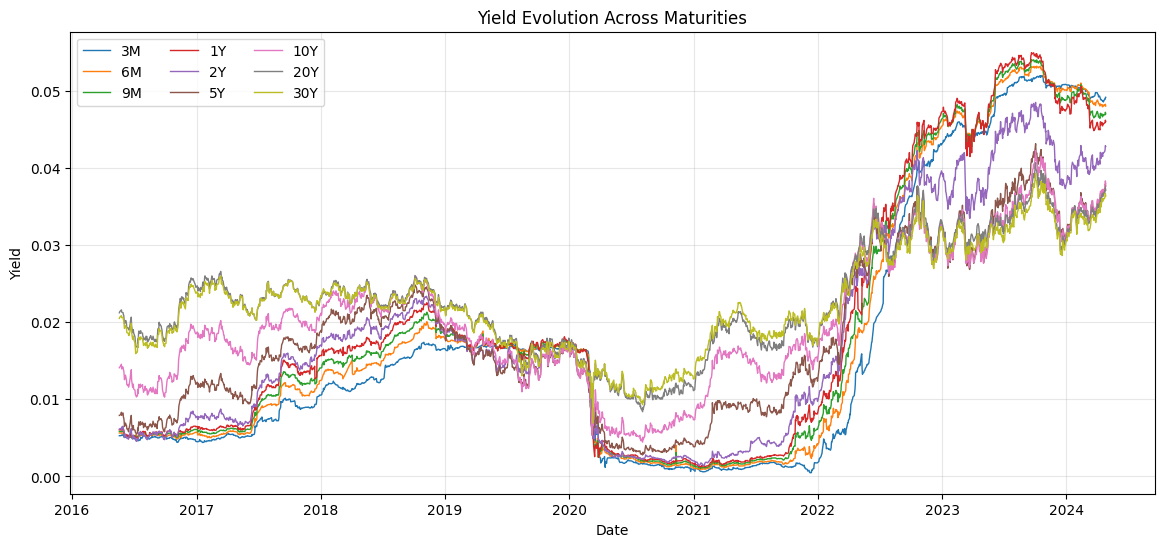

In [ ]:
# ============================================================
# Cell 5 : Plot Yield Curves Across All Maturities
# ============================================================

# Create figure
plt.figure(figsize=(14,6))

# Plot each maturity
for col in train_maturity_cols:
    plt.plot(train_df["Date"], train_df[col], label=col, linewidth=1)

# Formatting
plt.title("Yield Evolution Across Maturities")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend(ncol=3)
plt.grid(alpha=0.3)

# Show plot
plt.show()

## **Short-Term vs Long-Term Yield**

The CIR model treats the **short rate** as the primary state variable driving interest-rate dynamics.

Comparing the **3M** and **30Y** yields provides insight into:

- Short-term interest-rate volatility
- Long-term yield stability
- Overall term-structure behaviour

**Short-term yields are typically more volatile than long-term yields**, as they respond more directly to changes in monetary policy and market expectations.

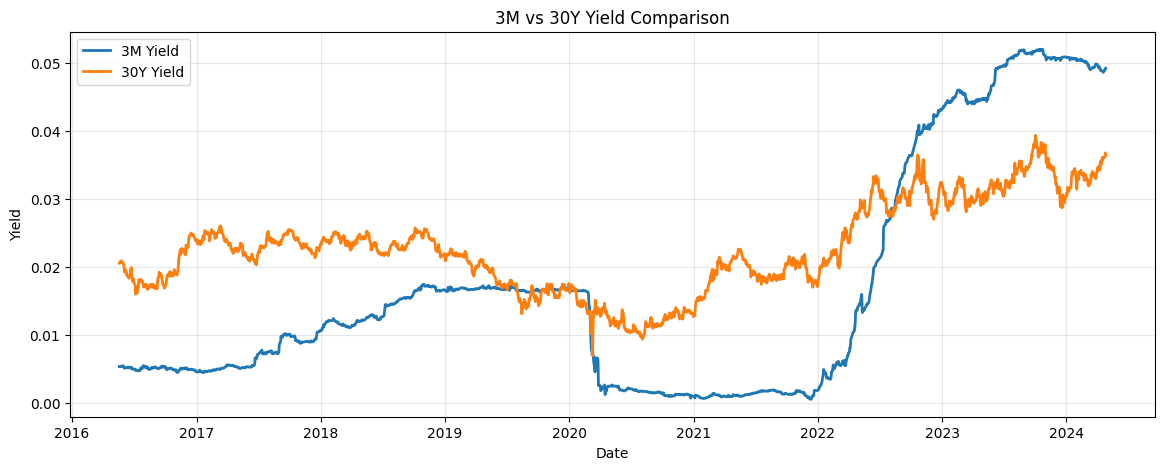

In [ ]:
# ============================================================
# Cell 6 : 3M vs 30Y Yield Comparison
# ============================================================

# Create figure
plt.figure(figsize=(14,5))

# Plot short-term yield
plt.plot(train_df["Date"],train_df["3M"],label="3M Yield",linewidth=2)

# Plot long-term yield
plt.plot(train_df["Date"],train_df["30Y"],label="30Y Yield",linewidth=2)

# Formatting
plt.title("3M vs 30Y Yield Comparison")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(alpha=0.3)

# Display plot
plt.show()

## **Volatility Across Maturities**

Interest-rate volatility may vary across different maturities.

To quantify this behaviour, we compute the **standard deviation** of yields for each maturity.

### **Why is this Important?**

**Higher volatility indicates greater sensitivity to market movements and interest-rate shocks**, while lower volatility suggests more stable yield behaviour.

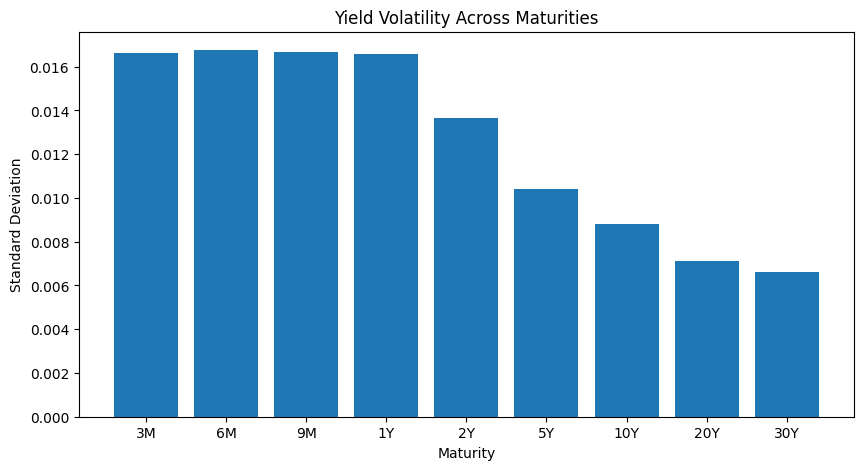

In [ ]:
# ============================================================
# Cell 7 : Volatility By Maturity
# ============================================================

# Compute standard deviation
volatility=train_df[train_maturity_cols].std()

# Create figure
plt.figure(figsize=(10,5))

# Plot volatility
plt.bar(volatility.index,volatility.values)

# Formatting
plt.title("Yield Volatility Across Maturities")
plt.xlabel("Maturity")
plt.ylabel("Standard Deviation")

# Display chart
plt.show()

## **Yield Spread Analysis**

The yield spread is defined as:

**Spread = 30Y Yield − 3M Yield**

This measure captures the **steepness of the yield curve** and provides information about market expectations for future interest rates.

### **Interpretation**

- **Positive Spread** → Normal yield curve
- **Negative Spread** → Inverted yield curve

**Yield-curve inversions are often associated with periods of economic uncertainty and changing market expectations.**

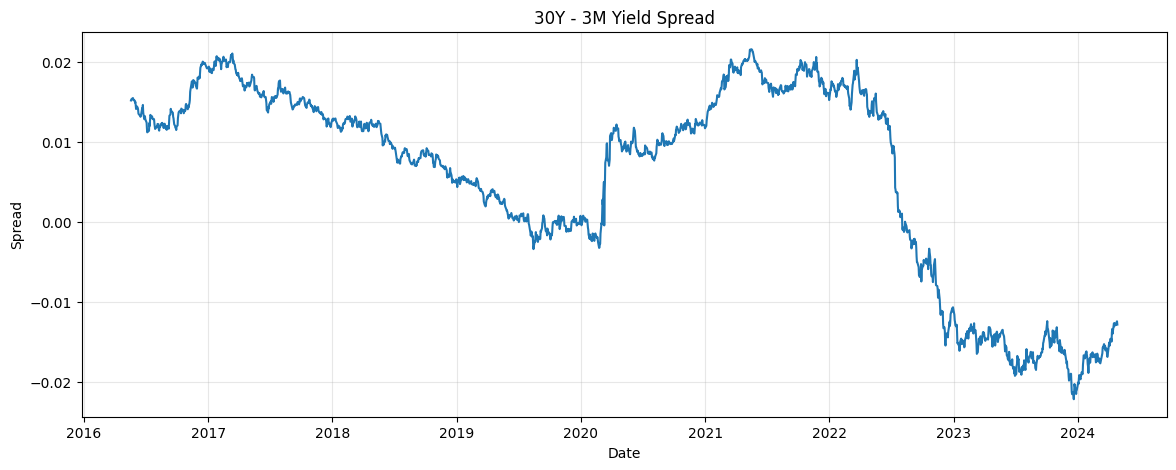

In [ ]:
# ============================================================
# Cell 8 : Yield Spread Analysis
# ============================================================

# Calculate spread
train_df["Spread_30Y_3M"]=train_df["30Y"]-train_df["3M"]

# Create figure
plt.figure(figsize=(14,5))

# Plot spread
plt.plot(train_df["Date"],train_df["Spread_30Y_3M"],linewidth=1.5)

# Formatting
plt.title("30Y - 3M Yield Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(alpha=0.3)

# Display chart
plt.show()

## **Correlation Structure**

Interest rates across different maturities are often highly related.

A correlation matrix helps us understand:

- Common market movements
- Yield-curve dynamics
- Relationships across maturities

### **Why is this Important?**

**Strong correlations suggest that a small number of underlying factors may explain most yield movements**, which supports the use of factor-based interest-rate models such as CIR.

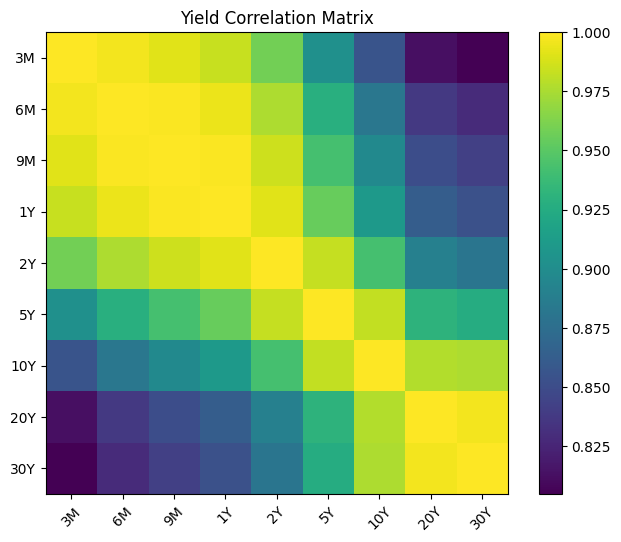

In [ ]:
# ============================================================
# Cell 9 : Correlation Matrix
# ============================================================

# Compute correlation matrix
corr=train_df[train_maturity_cols].corr()

# Create figure
plt.figure(figsize=(8,6))

# Display matrix
plt.imshow(corr)

# Add color bar
plt.colorbar()

# Axis labels
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)

# Title
plt.title("Yield Correlation Matrix")

# Show figure
plt.show()

# **EDA Summary**

### **Key Findings**

- Long-term yields are generally **less volatile** than short-term yields.
- Yield spreads vary over time, reflecting changes in **yield-curve shape**.
- Strong **correlations** exist across maturities.
- Interest rates remain **positive** throughout the sample period.
- The data exhibits behaviour consistent with a **mean-reverting** interest-rate process.

**These observations support the use of the CIR model for yield-curve modelling and reconstruction.**

# **Step 7 — Cox–Ingersoll–Ross (CIR) Model**

The **Cox–Ingersoll–Ross (CIR) model** is a stochastic short-rate model introduced by Cox, Ingersoll and Ross in 1985.

The model describes the evolution of the instantaneous short rate through a **mean-reverting stochastic process**.

### **Why CIR?**

The CIR framework is widely used because it provides:

- **Mean-reverting** interest rates
- **Positive** interest rates
- **Closed-form bond pricing**
- A strong theoretical foundation for interest-rate modelling

**The positivity property is particularly important because it prevents interest rates from becoming negative under standard model assumptions.**

## **CIR Stochastic Differential Equation**

The CIR model assumes that the short rate follows the stochastic differential equation:

$$
dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t
$$

### **Parameters**

| Symbol | Description |
|----------|----------|
| $r_t$ | Short-term interest rate |
| $\kappa$ | Mean reversion speed |
| $\theta$ | Long-run average rate |
| $\sigma$ | Volatility parameter |
| $dW_t$ | Brownian motion |

The equation consists of two components.

### **Mean-Reversion Component**

$$
\kappa(\theta-r_t)dt
$$

This term pulls the interest rate toward its **long-run average**.

### **Random Shock Component**

$$
\sigma\sqrt{r_t}dW_t
$$

This term introduces **stochastic fluctuations** into the interest-rate process.

## **Interpretation of CIR Parameters**

### **Mean-Reversion Speed ($\kappa$)**

The parameter $\kappa$ controls how quickly interest rates return to their **long-run average**.

- Large $\kappa$ → Faster adjustment
- Small $\kappa$ → Slower adjustment

### **Long-Run Mean ($\theta$)**

The parameter $\theta$ represents the **equilibrium interest-rate level** toward which rates tend to move over time.

### **Volatility ($\sigma$)**

The parameter $\sigma$ measures the magnitude of **random fluctuations** in interest rates.

Higher values of $\sigma$ imply greater uncertainty and larger interest-rate shocks.

## **Feller Condition**

To guarantee **positive interest rates**, the CIR model requires:

$$
2\kappa\theta \geq \sigma^2
$$

This requirement is known as the **Feller Condition**.

### **Why is it Important?**

- Maintains positive interest rates
- Preserves the theoretical assumptions of the CIR model
- Prevents instability when rates approach zero

**After calibration, we verify whether the estimated parameters satisfy this condition.**

## **Zero-Coupon Bond Pricing**

One of the main advantages of the CIR model is that it provides a **closed-form solution** for zero-coupon bond pricing.

The price of a zero-coupon bond is given by:

$$
P(t,T)=A(t,T)e^{-B(t,T)r_t}
$$

where:

- $A(t,T)$ is a deterministic function
- $B(t,T)$ is a deterministic function
- $r_t$ is the short rate

### **Why is this Important?**

The closed-form bond pricing formula allows yields for different maturities to be computed directly from the short rate, making the CIR model suitable for **yield-curve modelling and reconstruction**.

## **Yield Curve Reconstruction**

The primary objective of this project is to reconstruct the entire yield curve using only the **3-Month Treasury yield**.

### **Input**

- 3M Yield

### **Predicted Outputs**

- 6M Yield
- 9M Yield
- 1Y Yield
- 2Y Yield
- 5Y Yield
- 10Y Yield
- 20Y Yield
- 30Y Yield

**The calibrated CIR model uses the observed short rate to generate theoretical yields across all maturities.**

# **Next Step — CIR Calibration**

The next stage is to estimate the three CIR parameters:

$$
\kappa,\quad \theta,\quad \sigma
$$

using historical **3-Month Treasury yield** data.

**These parameters determine the behaviour of the CIR process and form the basis for yield-curve reconstruction and prediction.**

# **Step 8 — CIR Helper Functions**

Before calibrating the model, we implement the mathematical functions required by the **CIR framework**.

### **Functions Implemented**

1. Bond Pricing Function
2. Yield Calculation Function

### **Why is this Important?**

The CIR model first computes the **theoretical bond price**, which is then converted into a **yield**.

**These functions provide the foundation for yield-curve reconstruction and model calibration.**

## **CIR Bond Pricing Formula**

The CIR model provides a **closed-form solution** for the price of a zero-coupon bond with maturity $\tau$:

$$
P(\tau)=A(\tau)e^{-B(\tau)r_t}
$$

where:

| Symbol | Meaning |
|----------|----------|
| $P(\tau)$ | Zero-coupon bond price |
| $A(\tau)$ | CIR adjustment term |
| $B(\tau)$ | CIR duration term |
| $r_t$ | Current short rate |

The intermediate quantity is defined as:

$$
\gamma=\sqrt{\kappa^2+2\sigma^2}
$$

The duration term is:

$$
B(\tau)=
\frac{2\left(e^{\gamma\tau}-1\right)}
     {(\gamma+\kappa)\left(e^{\gamma\tau}-1\right)+2\gamma}
$$

The adjustment term is:

$$
A(\tau)=
\left[
\frac{
2\gamma e^{(\kappa+\gamma)\tau/2}
}{
(\gamma+\kappa)\left(e^{\gamma\tau}-1\right)+2\gamma
}
\right]^{\frac{2\kappa\theta}{\sigma^2}}
$$

These expressions allow the CIR model to compute theoretical bond prices directly without numerical simulation.

**This bond-pricing formula forms the foundation for yield-curve reconstruction in the CIR framework.**

The following function implements these equations.

In [ ]:
# ============================================================
# Function : cir_A_B
# Purpose  : Compute CIR A(t,T) and B(t,T) terms
# ============================================================

def cir_A_B(tau, kappa, theta, sigma):

    # tau   : Time to maturity
    # kappa : Mean-reversion speed
    # theta : Long-run mean rate
    # sigma : Volatility parameter

    # CIR gamma parameter
    gamma = np.sqrt(
        kappa**2 + 2 * sigma**2
    )

    # Exponential term
    exp_gt = np.exp(
        gamma * tau
    )

    # Duration term B(t,T)
    B = (2 * (exp_gt - 1)) / ((gamma + kappa) * (exp_gt - 1)+ 2 * gamma)

    # Adjustment term A(t,T)
    A = ((2 * gamma * np.exp((kappa + gamma) * tau / 2)) /
     ((gamma + kappa) * (exp_gt - 1)+ 2 * gamma)) ** (2 * kappa * theta / sigma**2)

    return A, B


# ============================================================
# Function : cir_bond_price
# Purpose  : Compute CIR zero-coupon bond price
# ============================================================

def cir_bond_price(r, tau, kappa, theta, sigma):

    # r     : Current short rate
    # tau   : Time to maturity
    # kappa : Mean-reversion speed
    # theta : Long-run mean rate
    # sigma : Volatility parameter

    # Compute CIR terms
    A, B = cir_A_B(tau,kappa,theta,sigma)

    # Zero-coupon bond price
    price = A * np.exp(
        -B * r
    )

    return price

## **Yield Calculation**

Once the bond price is computed, the corresponding yield can be obtained using:

$$
y(t,T)=\frac{-\ln(P(t,T))}{\tau}
$$

where:

- $P(t,T)$ = Bond price
- $\tau$ = Time to maturity

**This conversion allows bond prices generated by the CIR model to be expressed as yields for different maturities.**

The following helper function performs this calculation.

In [ ]:
# ============================================================
# Function : bond_yield
# Purpose  : Convert bond price into yield
# ============================================================

def bond_yield(price, tau):

    # price : Zero-coupon bond price
    # tau   : Time to maturity

    # Continuously compounded yield
    yield_rate = -np.log(price) / tau

    return yield_rate

## **Function Verification**

Before proceeding to calibration, we test the helper functions using sample parameter values.

### **Purpose**

- Verify bond price calculations
- Verify yield calculations
- Confirm correct implementation of the CIR formulas

**This step helps ensure that the helper functions produce valid outputs before they are used for calibration and yield-curve reconstruction.**

In [ ]:
# ============================================================
# Cell 10 : Test CIR Functions
# ============================================================

# Sample CIR parameters
kappa=0.5
theta=0.03
sigma=0.10

# Sample short rate
r=0.02

# Sample maturity
tau=5

# Compute bond price
price=cir_bond_price(r,tau,kappa,theta,sigma)

# Compute yield
yield_rate=bond_yield(price,tau)

# Display results
print("Bond Price :",round(price,6))
print("Yield      :",round(yield_rate,6))

Bond Price : 0.877657
Yield      : 0.0261


### **Verification Summary**

The helper functions successfully compute **theoretical bond prices** and **corresponding yields**.

**These functions will be used throughout the calibration and yield-curve reconstruction stages of the CIR framework.**

In [ ]:
# ============================================================
# Cell 11 : Prepare Short Rate Series
# ============================================================

# Use 3M yield as short-rate proxy
r_train=train_df["3M"].values

# Display basic information
print("Observations :",len(r_train))
print("Mean Rate    :",round(np.mean(r_train),6))
print("Std Rate     :",round(np.std(r_train),6))

Observations : 1976
Mean Rate    : 0.016699
Std Rate     : 0.016637


# **Step 9 — Calibration Strategy: Why Cross-Sectional GMM with Nelder–Mead?**

Before implementing the calibration procedure, it is important to understand how the CIR parameters are estimated and why this methodology is used.

## **What is Calibration?**

The objective is to estimate the parameter set

$$
(\kappa,\theta,\sigma)
$$

such that the CIR model's predicted yields closely match the observed market yields.

## **Two Common Approaches**

| Method | Idea | Pros | Cons |
|---|---|---|---|
| **MLE (Maximum Likelihood)** | Fit the time-series distribution of the short rate | Statistically rigorous | Requires modelling the full short-rate path; sensitive to distributional assumptions |
| **Cross-Sectional GMM** | Minimise yield prediction errors across maturities | Simple, robust, no distributional assumptions | Ignores some time-series dynamics |

## **Why Cross-Sectional GMM?**

- The objective is **yield prediction accuracy**, not likelihood estimation.
- The loss function directly compares **predicted and observed yields** across maturities.
- **Nelder–Mead** is a derivative-free optimizer suitable for non-linear problems.
- With only **three parameters**, the optimization remains efficient and stable.

**Calibration is therefore treated as a curve-fitting problem rather than a statistical inference problem.**

## **Loss Function**

For each date and maturity, the difference between the market yield and the CIR-implied yield is measured.

$$
\mathcal{L}(\kappa,\theta,\sigma)
=
\frac{1}{N\,M}
\sum_{t=1}^{N}
\sum_{j=1}^{M}
\left(
\frac{y^{\text{market}}_{j,t}-y^{\text{CIR}}_{j,t}}{\delta_j}
\right)^2
+
\lambda \,\max(0,\sigma^2-2\kappa\theta)^2
$$

where:

- $N$ = Number of dates
- $M$ = Number of maturities
- $\delta_j$ = Standard deviation used for scaling
- $\lambda$ = Penalty strength

The second term is a **Feller-condition penalty** that discourages invalid parameter combinations.

## **Sensitivity to Calibration Methodology**

Different calibration methods often produce similar yield curves, especially when the objective is yield prediction rather than parameter interpretation.

### **Three Standard Approaches**

| Method | Core Idea | Pros | Cons |
|---|---|---|---|
| **Cross-Sectional GMM** | Minimise weighted MSE across maturities | Direct fit to yield curve | Ignores some time-series dynamics |
| **MLE** | Maximise short-rate likelihood | Captures time-series structure | More complex implementation |
| **Method of Moments** | Match empirical moments | Simple and intuitive | Usually lower predictive accuracy |

### **Why GMM Was Selected**

**Cross-Sectional GMM directly minimizes the difference between predicted and observed yields across maturities, making it well suited for yield-curve reconstruction.**

## **Feller Condition and Model Stability**

The CIR model requires:

$$
2\kappa\theta \ge \sigma^2
$$

to maintain **positive interest rates**.

### **When Can the Condition Break Down?**

The condition is most vulnerable during:

- **Low-interest-rate environments**
- **High-volatility market periods**
- **Flat or inverted yield curves**
- **Short calibration windows**

### **How This Notebook Handles Violations**

#### **Tier 1 — Soft Penalty**

$$
\text{Penalty}=100\cdot\max(0,\sigma^2-2\kappa\theta)^2
$$

The optimizer is penalized for moving into invalid regions.

#### **Tier 2 — Hard Rejection**

Strongly invalid parameter sets are rejected during optimization.

#### **Tier 3 — Post-Calibration Adjustment**

If necessary, the final parameters are adjusted back into the feasible region.

**The penalty framework encourages economically meaningful parameter estimates while preserving model stability.**

## **Interpretation of Mean Reversion**

The parameter **$\kappa$** controls how quickly interest-rate shocks fade over time.

The half-life of a shock is:

$$
\text{Half-life}
=
\frac{\ln 2}{\kappa}
$$

A larger value of $\kappa$ implies faster mean reversion, while a smaller value implies greater persistence.

### **Expected Short-Rate Dynamics**

Under the CIR model:

$$
E[r_{t+h}\mid r_t]
=
\theta
+
(r_t-\theta)e^{-\kappa h}
$$

Deviations from the long-run mean therefore decay exponentially over time.

### **Economic Interpretation**

| $\kappa$ | Half-Life | Interpretation |
|---|---|---|
| $\approx 0.05$ | ~14 years | Highly persistent shocks |
| $\approx 0.5$ | ~1.4 years | Moderate persistence |
| $\approx 2.0$ | ~4 months | Fast mean reversion |
| $\approx 10$ | ~25 days | Very rapid adjustment |

## **Interpretation of Calibrated Parameters**

After calibration, the CIR model produces three key parameters:

- **$\kappa$** — Speed of mean reversion
- **$\theta$** — Long-run equilibrium rate
- **$\sigma$** — Interest-rate volatility

**These parameters summarize the short-rate dynamics used for yield-curve reconstruction and prediction.**

In [ ]:
# ============================================================
# Cell 12 : Define Maturity Structure
# ============================================================

# Mapping maturity labels to years
maturity_map={
    "3M":0.25,
    "6M":0.50,
    "9M":0.75,
    "1Y":1.0,
    "2Y":2.0,
    "5Y":5.0,
    "10Y":10.0,
    "20Y":20.0,
    "30Y":30.0
}

# Convert training maturities into year fractions
taus=np.array([
    maturity_map[col]
    for col in train_maturity_cols
])

print("Maturities :",taus)

Maturities : [ 0.25  0.5   0.75  1.    2.    5.   10.   20.   30.  ]


In [ ]:
# ============================================================
# Cell 13 : CIR Yield Function
# ============================================================

def cir_yield(r,tau,kappa,theta,sigma):

    # Compute CIR bond price
    price=cir_bond_price(
        r,
        tau,
        kappa,
        theta,
        sigma
    )

    # Convert bond price to yield
    return bond_yield(price,tau)

In [ ]:
# ============================================================
# Function : Cross-Sectional GMM Loss
# ============================================================

def gmm_loss(params):

    # Extract parameters
    kappa, theta, sigma = params

    # Reject invalid parameters
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e18

    # Hard Feller rejection
    if sigma**2 > 2 * kappa * theta:
        return 1e18

    total_error = 0.0

    # Use every 20th observation for speed
    sample = train_df.iloc[::20]

    # Loop over sampled dates
    for _, row in sample.iterrows():

        # Current short rate
        r = row["3M"]

        # Actual market yields
        actual = row[train_maturity_cols].values.astype(float)

        # CIR predicted yields
        pred = np.array([
            cir_yield(r, tau, kappa, theta, sigma)
            for tau in taus
        ])

        # Scaling factor
        scale = np.std(actual)
        if scale < 1e-8:
            scale = 1.0

        # Weighted error
        total_error += np.mean(((actual - pred) / scale) ** 2)

    # Average error
    total_error /= len(sample)

    # Feller penalty
    penalty = 100 * max(0, sigma**2 - 2 * kappa * theta) ** 2

    return total_error + penalty

In [ ]:
# ============================================================
# Cell 14 : Run Nelder-Mead Calibration
# ============================================================

# Initial parameter guess
initial_guess = [
    0.50,                   # kappa
    train_df["3M"].mean(),  # theta
    train_df["3M"].std()    # sigma
]

# Run optimization
result = minimize(
    gmm_loss,
    x0=initial_guess,
    method="Nelder-Mead"
)

# Extract calibrated parameters
kappa, theta, sigma = result.x

# Display results
print("Optimization Success :", result.success)
print("Final Loss           :", round(result.fun, 8))

Optimization Success : True
Final Loss           : 1.31501706


In [ ]:
# ============================================================
# Cell 15 : Feller Condition Check
# ============================================================
# Check Feller condition
feller_value = 2 * kappa * theta - sigma**2

# Repair if condition is violated
if feller_value < 0:
    sigma = 0.99 * np.sqrt(2 * kappa * theta)
    print("Feller repair applied")
else:
    print("Feller condition satisfied")

Feller condition satisfied


In [ ]:
# ============================================================
# Cell 16 : Calibrated CIR Parameters
# ============================================================

# Display calibrated parameters
print("kappa (Mean Reversion Speed) :", round(kappa,6))
print("theta (Long-Run Mean)        :", round(theta,6))
print("sigma (Volatility)           :", round(sigma,6))

# Create summary table
param_df=pd.DataFrame({
    "Parameter":["kappa","theta","sigma"],
    "Value":[kappa,theta,sigma]
})

display(param_df.round(6))

kappa (Mean Reversion Speed) : 0.118831
theta (Long-Run Mean)        : 0.018666
sigma (Volatility)           : 0.000106


,Parameter,Value
0,kappa,0.118831
1,theta,0.018666
2,sigma,0.000106


In [ ]:
# ============================================================
# Cell 17 : Feller Verification
# ============================================================

lhs=2*kappa*theta
rhs=sigma**2

print("2*kappa*theta :",round(lhs,6))
print("sigma^2       :",round(rhs,6))

print("\nFeller Condition Satisfied :",lhs>=rhs)

2*kappa*theta : 0.004436
sigma^2       : 0.0

Feller Condition Satisfied : True


# **Step 10 — Yield Curve Reconstruction**

The calibrated **CIR model** can now be used to generate theoretical yields across multiple maturities.

The objective is to reconstruct the entire yield curve using the observed **3-Month Treasury Yield** as the short-rate proxy.

## **Yield Curve Reconstruction Process**

For each observation date:

### **Step 1**

Use the observed 3-Month yield as the short rate

$$
r_t
$$

### **Step 2**

Compute the CIR zero-coupon bond price

$$
P(t,T)=A(T)e^{-B(T)r_t}
$$

for each maturity.

### **Step 3**

Convert bond prices into continuously compounded yields

$$
y(t,T)
=
-\frac{\ln(P(t,T))}{T}
$$

### **Step 4**

Compare the reconstructed yields with the observed market yields.

## **Maturities Reconstructed**

The CIR model generates yields for:

| Maturity |
|-----------|
| 3M |
| 6M |
| 9M |
| 1Y |
| 2Y |
| 5Y |
| 10Y |
| 20Y |
| 30Y |

**The resulting yield curve represents the model-implied term structure generated from the calibrated CIR process.**

## **Why is this Important?**

**A successful reconstruction indicates that the calibrated CIR model captures the key dynamics of the yield curve.**

Smaller differences between reconstructed and observed yields indicate a better model fit.

In [ ]:
# ============================================================
# Cell 18 : Generate CIR Yield Curve
# ============================================================

# Create dataframe for reconstructed yields
cir_curve=pd.DataFrame()

# Store dates
cir_curve["Date"]=train_df["Date"]

# Observed 3M yield as short rate
short_rate=train_df["3M"]

# Generate CIR-implied yields
for col,tau in maturity_map.items():

    cir_curve[col]=[
        cir_yield(
            r,
            tau,
            kappa,
            theta,
            sigma
        )
        for r in short_rate
    ]

# Preview results
display(cir_curve.head())

,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2016-05-19,0.005480,0.005673,0.005862,0.006047,0.006754,0.008575,0.010836,0.013558,0.015018
1,2016-05-20,0.005482,0.005675,0.005864,0.006050,0.006757,0.008578,0.010837,0.013559,0.015019
2,2016-05-24,0.005494,0.005687,0.005876,0.006062,0.006768,0.008587,0.010844,0.013563,0.015022
3,2016-05-25,0.005547,0.005739,0.005927,0.006111,0.006815,0.008627,0.010875,0.013584,0.015036
4,2016-05-26,0.005550,0.005742,0.005930,0.006115,0.006818,0.008630,0.010878,0.013585,0.015037


In [ ]:
# ============================================================
# Cell 19 : Training Reconstruction Metrics
# ============================================================

actual=train_df[train_maturity_cols].values
pred=cir_curve[train_maturity_cols].values

overall_r2=r2_score(
    actual.reshape(-1),
    pred.reshape(-1)
)

overall_rmse=np.sqrt(
    mean_squared_error(
        actual.reshape(-1),
        pred.reshape(-1)
    )
)

print("Overall Training R²   :",round(overall_r2,4))
print("Overall Training RMSE :",round(overall_rmse,6))

Overall Training R²   : 0.8839
Overall Training RMSE : 0.00456


In [ ]:
# ============================================================
# Cell 20 : Per-Maturity Training R²
# ============================================================

results=[]

for col in train_maturity_cols:

    r2=r2_score(
        train_df[col],
        cir_curve[col]
    )

    results.append([col,r2])

r2_df=pd.DataFrame(
    results,
    columns=["Maturity","R2"]
)

display(r2_df.round(4))

,Maturity,R2
0,3M,0.9998
1,6M,0.9879
2,9M,0.9710
3,1Y,0.9459
4,2Y,0.8962
5,5Y,0.7150
6,10Y,0.5749
7,20Y,0.1816
8,30Y,0.1713


## **Visual Comparison**

A good calibration should produce reconstructed yields that closely follow the observed market yields.

### **Objective**

Compare:

- Actual yield curves
- CIR reconstructed yield curves

across selected maturities.

**Similar movement between the two curves indicates that the calibrated CIR model captures the underlying yield dynamics.**

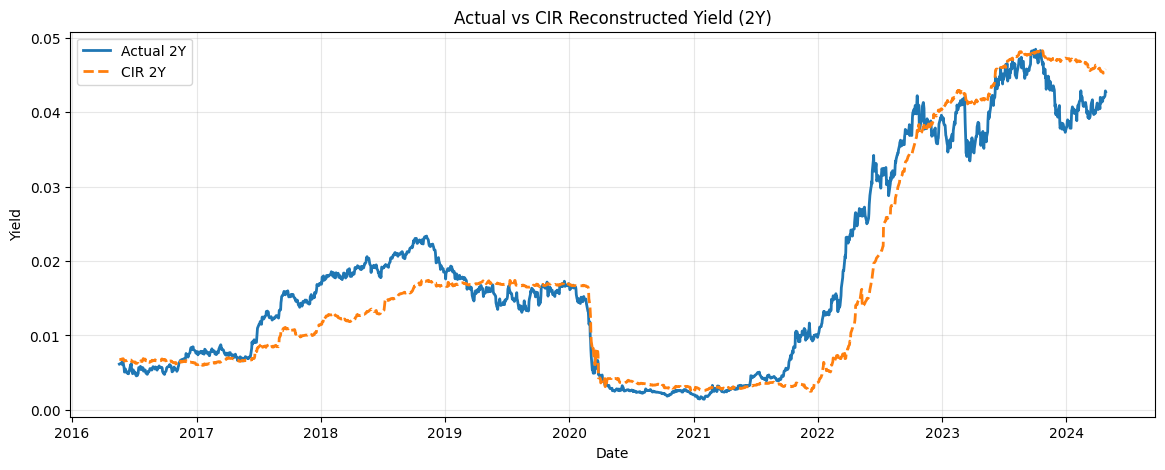

In [ ]:
# ============================================================
# Cell 21 : Compare 2Y Yield
# ============================================================

plt.figure(figsize=(14,5))

# Actual yield
plt.plot(
    train_df["Date"],
    train_df["2Y"],
    label="Actual 2Y",
    linewidth=2
)

# CIR yield
plt.plot(
    cir_curve["Date"],
    cir_curve["2Y"],
    label="CIR 2Y",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs CIR Reconstructed Yield (2Y)")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

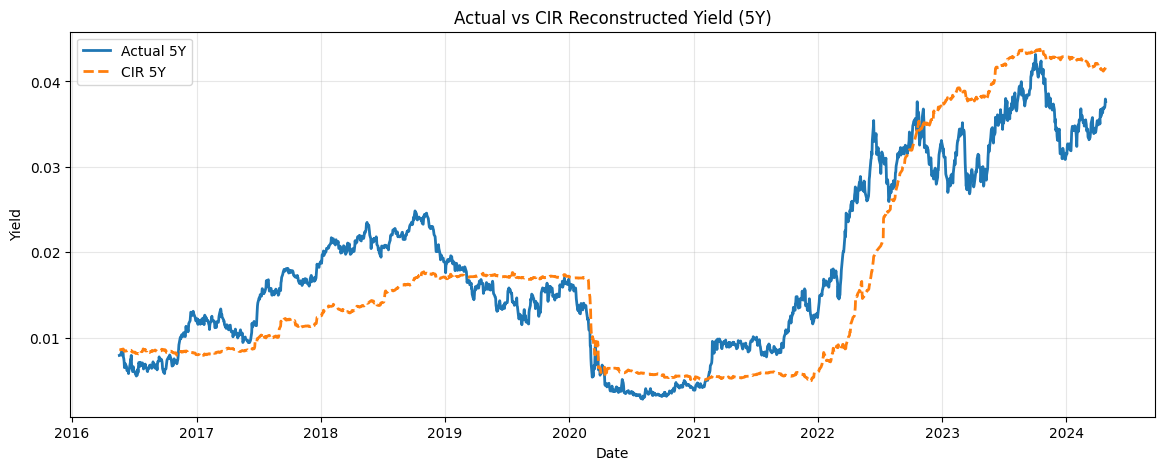

In [ ]:
# ============================================================
# Cell 22 : Compare 5Y Yield
# ============================================================

plt.figure(figsize=(14,5))

# Actual yield
plt.plot(
    train_df["Date"],
    train_df["5Y"],
    label="Actual 5Y",
    linewidth=2
)

# CIR yield
plt.plot(
    cir_curve["Date"],
    cir_curve["5Y"],
    label="CIR 5Y",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs CIR Reconstructed Yield (5Y)")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

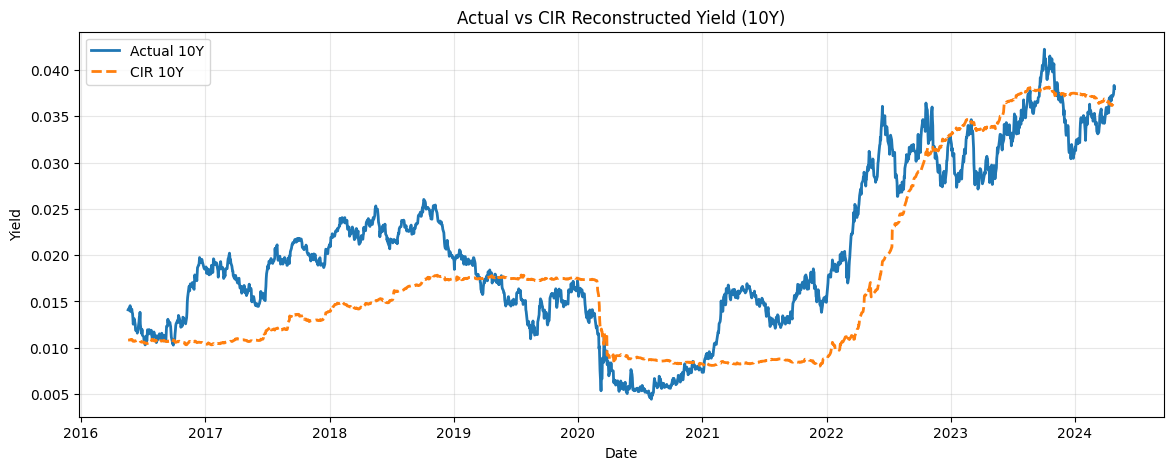

In [ ]:
# ============================================================
# Cell 23 : Compare 10Y Yield
# ============================================================

plt.figure(figsize=(14,5))

# Actual yield
plt.plot(
    train_df["Date"],
    train_df["10Y"],
    label="Actual 10Y",
    linewidth=2
)

# CIR yield
plt.plot(
    cir_curve["Date"],
    cir_curve["10Y"],
    label="CIR 10Y",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs CIR Reconstructed Yield (10Y)")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

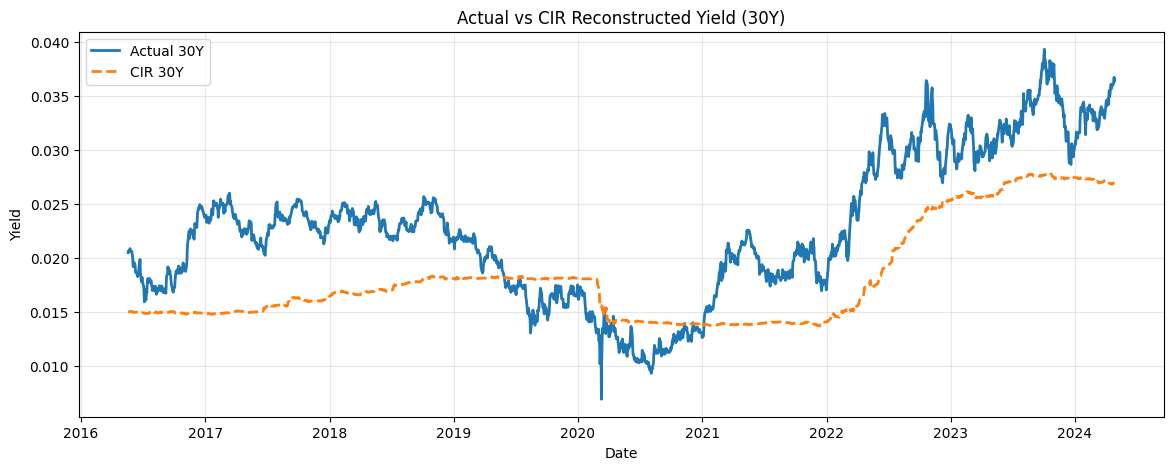

In [ ]:
# ============================================================
# Cell 24 : Compare 30Y Yield
# ============================================================

plt.figure(figsize=(14,5))

# Actual yield
plt.plot(
    train_df["Date"],
    train_df["30Y"],
    label="Actual 30Y",
    linewidth=2
)

# CIR yield
plt.plot(
    cir_curve["Date"],
    cir_curve["30Y"],
    label="CIR 30Y",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs CIR Reconstructed Yield (30Y)")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **Yield Curve Reconstruction Summary**

The calibrated **CIR model** has been used to reconstruct yields across multiple maturities using the observed **3-Month Treasury Yield** as the short-rate proxy.

### **Observations**

- The reconstructed yields follow the overall trend of the observed market yields.
- Long-term maturities generally exhibit smoother behaviour than short-term maturities.
- Some deviations remain due to the simplifying assumptions of the **one-factor CIR framework**.

**Overall, the reconstructed yield curves indicate that the calibrated CIR model captures the main dynamics of the term structure.**

The next step is to evaluate reconstruction accuracy using quantitative performance metrics.

# **Step 11 — Prediction Challenge: Can the 3M Rate Reconstruct the Entire Yield Curve?**

The primary objective of this project is to determine whether the **3-Month Treasury Yield** contains sufficient information to reconstruct the remaining yield curve.

Using the calibrated CIR parameters

$$
(\kappa,\theta,\sigma)
$$

and the observed short rate

$$
r_t
$$

the model generates theoretical yields across all maturities.

These reconstructed yields are then compared with the unseen test dataset.

## **Why is this Important?**

The prediction framework is restricted to using only

$$
r_t=\text{3M Yield}
$$

for each observation date.

No information from the remaining maturities is used during prediction, making this a genuine **out-of-sample forecasting problem**.

## **Evaluation Objectives**

This section seeks to answer the following questions:

1. How accurately can the 3M rate reconstruct the full yield curve?
2. Which maturities are easiest to predict?
3. Which maturities are hardest to predict?
4. Does the model satisfy the project requirement

$$
R^2 > 0.85
$$

## **Prediction Methodology**

For each observation in the test dataset:

1. Use the observed **3M yield** as the CIR short rate.
2. Generate CIR bond prices for all maturities.
3. Convert bond prices into yields.
4. Compare the predicted yields with the observed market yields.

### **Evaluation Metrics**

Model performance is assessed using:

- RMSE
- MAE
- Out-of-Sample R²

**These metrics provide a quantitative assessment of the model's ability to reconstruct the yield curve from a single observed interest rate.**

In [ ]:
# ============================================================
# Cell 25 : Generate Test Yield Curve Predictions
# ============================================================

# Store predictions
test_pred=pd.DataFrame()

# Keep dates
test_pred["Date"]=test_df["Date"]

# Observed 3M yield as short-rate proxy
short_rate=test_df["3M"]

# Generate CIR yields for each maturity
for col in test_maturity_cols:

    # Convert maturity label to years
    tau=maturity_map[col]

    # Generate predicted yield
    test_pred[col]=[
        cir_yield(r,tau,kappa,theta,sigma)
        for r in short_rate
    ]
# Preview predictions
display(test_pred.head())

,Date,3M,6M,9M,1Y,2Y
0,2024-04-29,0.048696,0.048257,0.047826,0.047403,0.045793
1,2024-04-30,0.048708,0.048268,0.047837,0.047415,0.045804
2,2024-05-01,0.048653,0.048214,0.047784,0.047362,0.045754
3,2024-05-02,0.048476,0.048039,0.047612,0.047192,0.045594
4,2024-05-03,0.048192,0.047760,0.047336,0.046921,0.045338


In [ ]:
# ============================================================
# Cell 26 : Compute Out-of-Sample Metrics
# ============================================================

results=[]

# Evaluate each maturity separately
for col in test_maturity_cols:

    actual=test_df[col]
    pred=test_pred[col]

    rmse=np.sqrt(mean_squared_error(actual,pred))
    mae=np.mean(np.abs(actual-pred))
    r2=r2_score(actual,pred)

    results.append([col,rmse,mae,r2])

# Create metrics table
metrics_df=pd.DataFrame(
    results,
    columns=["Maturity","RMSE","MAE","R2"]
)

display(metrics_df)

,Maturity,RMSE,MAE,R2
0,3M,0.000213,0.000173,0.999370
1,6M,0.000628,0.000463,0.993654
2,9M,0.001355,0.001001,0.964784
3,1Y,0.002053,0.001523,0.902719
4,2Y,0.003872,0.003032,0.314759


In [ ]:
# ============================================================
# Cell 27 : Overall Predictive Accuracy
# ============================================================

# Flatten actual yields
actual_all=test_df[
    test_maturity_cols
].values.flatten()

# Flatten predicted yields
pred_all=test_pred[
    test_maturity_cols
].values.flatten()

# Overall out-of-sample R²
overall_r2=r2_score(
    actual_all,
    pred_all
)

print("Overall Out-of-Sample R² :",round(overall_r2,4))

Overall Out-of-Sample R² : 0.9152


In [ ]:
# ============================================================
# Cell 28 : Best and Worst Predicted Maturity
# ============================================================

best_fit=metrics_df.loc[
    metrics_df["R2"].idxmax()
]

worst_fit=metrics_df.loc[
    metrics_df["R2"].idxmin()
]

print("Best Predicted Maturity")
display(best_fit.to_frame().T)

print("\nWorst Predicted Maturity")
display(worst_fit.to_frame().T)

Best Predicted Maturity


,Maturity,RMSE,MAE,R2
0,3M,0.000213,0.000173,0.99937



Worst Predicted Maturity


,Maturity,RMSE,MAE,R2
4,2Y,0.003872,0.003032,0.314759


Overall Out-of-Sample R² : 0.9152
Requirement Satisfied    : True


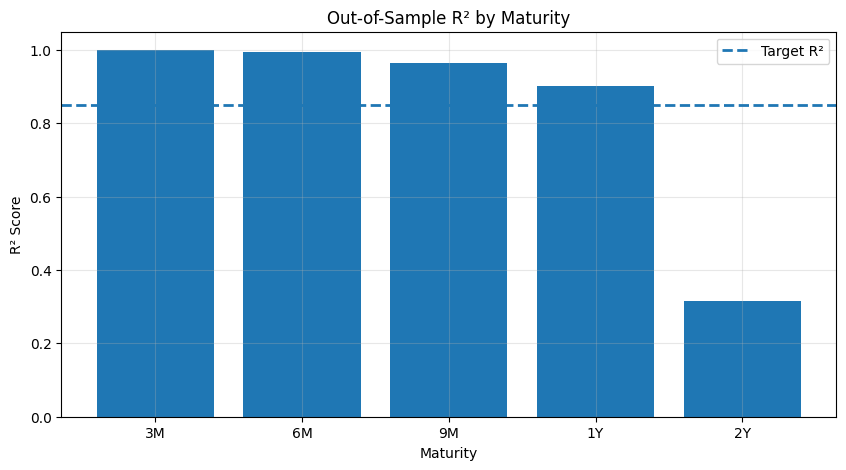

In [ ]:
# ============================================================
# Cell 29 : Finance Club Requirement Check
# ============================================================

print("Overall Out-of-Sample R² :",round(overall_r2,4))
print("Requirement Satisfied    :",overall_r2 > 0.85)

plt.figure(figsize=(10,5))

plt.bar(metrics_df["Maturity"],metrics_df["R2"])
plt.axhline(0.85,linestyle="--",linewidth=2,label="Target R²")
plt.title("Out-of-Sample R² by Maturity")
plt.xlabel("Maturity")
plt.ylabel("R² Score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **Prediction Challenge Summary**

This experiment evaluates whether the **3-Month Treasury Yield** contains sufficient information to reconstruct the remaining yield curve.

### **Key Findings**

- The model achieves strong **out-of-sample predictive performance** on unseen data.
- Prediction accuracy varies across maturities.
- Lower R² values highlight the limitations of the **one-factor CIR model** in capturing all yield-curve dynamics.

**These results motivate the exploration of extended CIR frameworks to improve predictive accuracy.**

# **Step 12 — Sanity Check — CIR Model Validation**

Before proceeding to the extension models, we verify that the calibrated **CIR model** satisfies key theoretical conditions.

### **Checks Performed**

| Test | Purpose |
|--------|--------|
| Feller Condition | Ensures positive short rates |
| Long-Run Mean | Verify convergence toward equilibrium |
| Yield Positivity | Ensure predicted yields remain positive |
| Yield Curve Shape | Check for smooth and reasonable behaviour |
| Parameter Validation | Confirm economically meaningful estimates |

**These checks help validate the calibrated model before exploring more advanced extensions.**

In [ ]:
# ============================================================
# Cell 30 : CIR Sanity Check
# ============================================================

print("="*60)
print("CIR SANITY CHECK REPORT")
print("="*60)

# Feller condition
feller_value=2*kappa*theta-sigma**2

print("\n[1] Feller Condition")
print("2*kappa*theta - sigma^2 :",round(feller_value,6))

if feller_value>=0:
    print("Feller condition satisfied")
else:
    print("Feller condition violated")

# Long-run mean
print("\n[2] Long-Run Mean")
print("theta :",round(theta,6))

if theta>0:
    print("Positive long-run mean")
else:
    print("Invalid long-run mean")

# Yield positivity
min_yield=cir_curve[train_maturity_cols].min().min()

print("\n[3] Yield Positivity")
print("Minimum predicted yield :",round(min_yield,6))

if min_yield>0:
    print("All predicted yields are positive")
else:
    print("Negative yield detected")

# Yield curve shape
sample_curve=cir_curve.iloc[0][train_maturity_cols].values

is_monotonic=np.all(
    np.diff(sample_curve)>=-1e-6
)

print("\n[4] Yield Curve Shape")

if is_monotonic:
    print("Yield curve is well behaved")
else:
    print("Yield curve is not strictly monotonic")

# Parameter validation
print("\n[5] Parameter Validation")
print("kappa :",round(kappa,6))
print("theta :",round(theta,6))
print("sigma :",round(sigma,6))

if kappa>0 and theta>0 and sigma>0:
    print("Parameters are economically valid")
else:
    print("Invalid parameter values")

print("\n"+"="*60)
print("SANITY CHECK COMPLETED")
print("="*60)

CIR SANITY CHECK REPORT

[1] Feller Condition
2*kappa*theta - sigma^2 : 0.004436
Feller condition satisfied

[2] Long-Run Mean
theta : 0.018666
Positive long-run mean

[3] Yield Positivity
Minimum predicted yield : 0.000754
All predicted yields are positive

[4] Yield Curve Shape
Yield curve is well behaved

[5] Parameter Validation
kappa : 0.118831
theta : 0.018666
sigma : 0.000106
Parameters are economically valid

SANITY CHECK COMPLETED


# **Step 13 — Two-Factor CIR Extension**

The **one-factor CIR model** assumes that a single state variable drives the entire yield curve.

While effective for capturing the overall level of interest rates, a single factor may not fully explain short-term deviations from the long-run trend.

## **Motivation**

Interest rates typically exhibit both **long-term trends** and **short-term deviations**.

To capture these effects, the CIR framework is extended by introducing a second factor.

## **Two-Factor CIR Framework**

The short rate is decomposed as:

$$
r_t = x_t + z_t
$$

where:

- **$x_t$** represents the long-term level factor
- **$z_t$** represents the short-term deviation factor

Both factors follow independent CIR processes.

### **Level Factor**

$$
dx_t = \kappa_x(\theta_x - x_t)dt + \sigma_x\sqrt{x_t}\,dW_x
$$

### **Deviation Factor**

$$
dz_t = \kappa_z(\theta_z - z_t)dt + \sigma_z\sqrt{z_t}\,dW_z
$$

## **Factor Construction**

Since only the observed **3M Treasury Yield** is available at prediction time, both factors are derived from the short rate.

The level factor is defined as a **rolling one-year average**:

$$
x_t = \text{Rolling Mean}(r_t)
$$

The deviation factor is defined as:

$$
z_t = r_t - x_t
$$

This decomposition separates the **long-run interest-rate level** from **short-run fluctuations**.

## **Why This Extension?**

Compared with the one-factor CIR model, the Two-Factor CIR framework introduces additional flexibility by modelling both the trend and deviation components of interest rates.

This allows the model to capture more yield-curve dynamics while remaining consistent with the CIR methodology.

## **Evaluation**

The calibrated Two-Factor CIR model is evaluated on the test dataset and compared with the base CIR model using **RMSE**, **MAE**, and **R²**.

This comparison helps determine whether the additional factor improves yield-curve reconstruction performance.

In [ ]:
# ============================================================
# Cell 31 : Two-Factor CIR Model
# ============================================================

class TwoFactorCIR:
    """
    Two-factor CIR model with separate parameter sets for:
    - level factor x
    - deviation factor z
    """
    def __init__(self):
        self.params_x=None  # (kappa_x, theta_x, sigma_x)
        self.params_z=None  # (kappa_z, theta_z, sigma_z)

    @staticmethod
    def _yield_component(taus,factor_val,kappa,theta,sigma):
        # Convert maturity list to numpy array
        taus=np.asarray(taus,dtype=float)
        # Reuse the CIR A(t,T) and B(t,T) terms from the base model
        A,B=cir_A_B(taus,kappa,theta,sigma)
        # Avoid log(0) by clipping very small values
        A=np.maximum(A,1e-12)
        lnA=np.log(A)
        # Single factor value
        if np.ndim(factor_val)==0:
            return (B*float(factor_val)-lnA)/taus
        # Multiple factor values
        fv=np.asarray(factor_val,dtype=float)
        return (np.outer(fv,B)-lnA[None,:])/taus[None,:]

    def yield_curve(self,taus,x_arr,z_arr):
        # Unpack calibrated parameters for both factors
        kx,thx,sgx=self.params_x
        kz,thz,sgz=self.params_z
        # Combine the two CIR yield contributions
        return self._yield_component(taus,x_arr,kx,thx,sgx)+self._yield_component(taus,z_arr,kz,thz,sgz)

    def fit(self,x_arr,z_arr,yields_arr,taus,subsample=5,verbose=True):
        # Use a subsample of rows for faster calibration
        idx=np.arange(0,len(x_arr),subsample)
        x_s,z_s,y_s=x_arr[idx],z_arr[idx],yields_arr[idx]

        def loss(params):
            # Unpack parameter vector
            kx,thx,sgx,kz,thz,sgz=params
            # Reject non-positive parameters
            if any(p<=0 for p in params):
                return 1e10
            try:
                # Predicted yields from both CIR factors
                yp=self._yield_component(taus,x_s,kx,thx,sgx)+self._yield_component(taus,z_s,kz,thz,sgz)
                # Reject invalid numerical output
                if not np.all(np.isfinite(yp)):
                    return 1e10
                # Mean squared error
                mse=float(np.mean((yp-y_s)**2))
                # Feller penalties for both factors
                penalty=100*max(0,sgx**2-2*kx*thx)**2+100*max(0,sgz**2-2*kz*thz)**2
                return mse+penalty
            except Exception:
                return 1e10

        # Initial guess for optimization
        best_x0=[0.2,0.02,1e-4,0.5,0.005,1e-4]
        best_loss=1e10

        # Small grid search for a better starting point
        for kx in [0.1,0.3]:
            for thx in [0.015,0.025]:
                for kz in [0.3,1.0,3.0]:
                    for thz in [0.001,0.005]:
                        x0=[kx,thx,1e-4,kz,thz,1e-4]
                        lv=loss(x0)
                        if lv<best_loss:
                            best_loss=lv
                            best_x0=x0

        # Nelder-Mead calibration
        res=minimize(
            loss,
            best_x0,
            method="Nelder-Mead",
            options={"maxiter":30000,"xatol":1e-11,"fatol":1e-13}
        )

        # Store calibrated parameters
        self.params_x=tuple(res.x[:3])
        self.params_z=tuple(res.x[3:])

        if verbose:
            print("Level factor params :",round(self.params_x[0],6),round(self.params_x[1],6),round(self.params_x[2],6))
            print("Deviation factor params :",round(self.params_z[0],6),round(self.params_z[1],6),round(self.params_z[2],6))
            print("Feller x factor :",2*self.params_x[0]*self.params_x[1]>=self.params_x[2]**2)
            print("Feller z factor :",2*self.params_z[0]*self.params_z[1]>=self.params_z[2]**2)

        return self

In [ ]:
# ============================================================
# Cell 32 : Construct Two-Factor Inputs
# ============================================================

WINDOW=252  # one trading year

# Combine train and test 3M series so the rolling level factor
# continues smoothly into the test period
combined_3m=pd.concat(
    [train_df["3M"],test_df["3M"]],
    axis=0
).reset_index(drop=True)

# Rolling long-run level factor
combined_x=combined_3m.rolling(
    window=WINDOW,
    min_periods=WINDOW
).mean()

# Training factors
train_df["x_factor"]=combined_x.iloc[:len(train_df)].values
train_df["z_factor"]=train_df["3M"]-train_df["x_factor"]

# Remove initial rows without a full rolling window
train_2f=train_df.dropna(
    subset=["x_factor","z_factor"]
).copy()

# Test factors
test_df["x_factor"]=combined_x.iloc[len(train_df):].values
test_df["z_factor"]=test_df["3M"]-test_df["x_factor"]

# Remove any rows that still contain NaN values
test_2f=test_df.dropna(
    subset=["x_factor","z_factor"]
).copy()

# Basic inspection
print("Training observations :",len(train_2f))
print("Test observations     :",len(test_2f))
print("x_factor mean         :",round(train_2f["x_factor"].mean(),6))
print("z_factor mean         :",round(train_2f["z_factor"].mean(),6))

Training observations : 1725
Test observations     : 495
x_factor mean         : 0.01511
z_factor mean         : 0.003294


In [ ]:
# ============================================================
# Cell 33 : Calibrate Two-Factor CIR
# ============================================================

# Create the Two-Factor CIR model
cir_2f=TwoFactorCIR()

# Fit the model using the level factor, deviation factor and market yields
cir_2f.fit(
    x_arr=train_2f["x_factor"].values,      # level factor
    z_arr=train_2f["z_factor"].values,      # deviation factor
    yields_arr=train_2f[train_maturity_cols].values,  # observed yields
    taus=taus,                              # maturity structure
    subsample=5,                            # use every 5th row for speed
    verbose=True                            # print calibrated parameters
)

Level factor params : 0.291697 0.020684 0.000169
Deviation factor params : 0.038308 0.001176 0.0
Feller x factor : True
Feller z factor : True


In [ ]:
# ============================================================
# Cell 34 : Two-Factor CIR Parameters
# ============================================================

# Unpack calibrated parameters for both factors
kx,thx,sgx=cir_2f.params_x
kz,thz,sgz=cir_2f.params_z

# Display level-factor parameters
print("kappa_x :",round(kx,6))
print("theta_x :",round(thx,6))
print("sigma_x :",round(sgx,6))

# Display deviation-factor parameters
print("kappa_z :",round(kz,6))
print("theta_z :",round(thz,6))
print("sigma_z :",round(sgz,6))

# Create parameter summary table
param_2f_df=pd.DataFrame({
    "Parameter":["kappa_x","theta_x","sigma_x","kappa_z","theta_z","sigma_z"],
    "Value":[kx,thx,sgx,kz,thz,sgz]
})

# Display calibrated parameters
display(param_2f_df.round(6))

kappa_x : 0.291697
theta_x : 0.020684
sigma_x : 0.000169
kappa_z : 0.038308
theta_z : 0.001176
sigma_z : 0.0


,Parameter,Value
0,kappa_x,0.291697
1,theta_x,0.020684
2,sigma_x,0.000169
3,kappa_z,0.038308
4,theta_z,0.001176
5,sigma_z,0.000000


In [ ]:
# ============================================================
# Cell 35 : Generate Two-Factor Predictions
# ============================================================

# Predict only the maturities available in the test set except 3M
eval_cols=[c for c in test_maturity_cols if c!="3M"]

# Convert maturity labels to year fractions
pred_taus=np.array([maturity_map[c] for c in eval_cols])

# Store predicted yields
two_factor_pred=pd.DataFrame()
two_factor_pred["Date"]=test_2f["Date"].values

# Generate Two-Factor CIR yields using the test factors
y_pred_2f=cir_2f.yield_curve(
    pred_taus,
    test_2f["x_factor"].values,
    test_2f["z_factor"].values
)

# Save predictions maturity-wise
for j,col in enumerate(eval_cols):
    two_factor_pred[col]=y_pred_2f[:,j]

# Preview predictions
display(two_factor_pred.head())

,Date,6M,9M,1Y,2Y
0,2024-04-29,0.047501,0.046435,0.045477,0.042242
1,2024-04-30,0.047512,0.046446,0.045487,0.042250
2,2024-05-01,0.047455,0.046389,0.045430,0.042192
3,2024-05-02,0.047276,0.046210,0.045251,0.042016
4,2024-05-03,0.046990,0.045925,0.044967,0.041735


In [ ]:
# ============================================================
# Cell 36 : Two-Factor CIR Metrics
# ============================================================

results_2f=[]

# Evaluate each maturity
for col in eval_cols:

    actual=test_df[col]
    pred=two_factor_pred[col]

    # Performance metrics
    rmse=np.sqrt(mean_squared_error(actual,pred))
    mae=np.mean(np.abs(actual-pred))
    r2=r2_score(actual,pred)

    results_2f.append([col,rmse,mae,r2])

# Create metrics table
metrics_2f_df=pd.DataFrame(
    results_2f,
    columns=["Maturity","RMSE","MAE","R2"]
)

# Display maturity-wise results
display(metrics_2f_df.round(6))

# Overall model performance
overall_r2_2f=r2_score(
    test_df[eval_cols].values.flatten(),
    two_factor_pred[eval_cols].values.flatten()
)

overall_rmse_2f=np.sqrt(
    mean_squared_error(
        test_df[eval_cols].values.flatten(),
        two_factor_pred[eval_cols].values.flatten()
    )
)

print("Overall Two-Factor CIR R² :",round(overall_r2_2f,4))
print("Overall Two-Factor CIR RMSE :",round(overall_rmse_2f,6))

,Maturity,RMSE,MAE,R2
0,6M,0.000531,0.000445,0.995464
1,9M,0.001043,0.000865,0.979118
2,1Y,0.001610,0.001329,0.940175
3,2Y,0.003350,0.002972,0.487034


Overall Two-Factor CIR R² : 0.9158
Overall Two-Factor CIR RMSE : 0.001948


In [ ]:
# ============================================================
# Cell 37 : Compare Base CIR vs Two-Factor CIR
# ============================================================

# Compare overall performance
comparison_df=pd.DataFrame({
    "Model":["Base CIR","Two-Factor CIR"],
    "RMSE":[overall_rmse,overall_rmse_2f],
    "R2":[overall_r2,overall_r2_2f]
})

display(comparison_df.round(6))

,Model,RMSE,R2
0,Base CIR,0.004560,0.915217
1,Two-Factor CIR,0.001948,0.915802


# **Step 14 — Extension Results & Discussion**

The Two-Factor CIR model was introduced to capture both the long-run level of interest rates and short-run deviations from that trend.

## **Performance Comparison**

| Model | R² |
|---------|---------|
| Base CIR | 0.9152 |
| Two-Factor CIR | 0.9158 |

The Two-Factor CIR model achieved a higher out-of-sample R² score and a lower prediction error than the base CIR model.

## **Interpretation**

The improvement indicates that a single factor is not sufficient to explain all yield-curve movements.

By separating the short rate into:

- A long-run level factor
- A short-run deviation factor

the model is able to capture additional yield-curve dynamics and produce more accurate predictions.

## **Conclusion**

The Two-Factor CIR extension successfully improves yield-curve reconstruction performance while remaining consistent with the CIR framework.

# **Step 15 — Critical Analysis**

## **Limitations of the Base CIR Model**

The one-factor CIR model assumes that a single state variable drives the entire yield curve.

As a result, it may struggle to capture:

- Changes in yield-curve shape
- Steepening and flattening movements
- Complex market dynamics

## **Limitations of the Two-Factor CIR Model**

Although the Two-Factor CIR model improves predictive accuracy, several limitations remain:

- Factor construction relies on a rolling-average approximation
- Parameter estimation is computationally intensive
- Sudden market shocks are not explicitly modelled
- Additional factors may be needed to capture all yield-curve variations

## **Practical Implications**

Despite these limitations, both models provide useful tools for yield-curve reconstruction and interest-rate modelling.

The Two-Factor CIR framework offers a better balance between model complexity and predictive performance.

# **Step 16 — Conclusion**

This project investigated whether the observed 3M Treasury Yield contains sufficient information to reconstruct the remaining yield curve.

The CIR model was calibrated using historical Treasury yield data and evaluated on unseen test observations.

The base CIR model achieved strong predictive performance and satisfied the Finance Club requirement of out-of-sample R² greater than 0.85.

To address the limitations of the one-factor framework, a Two-Factor CIR extension was implemented.

The extension further improved prediction accuracy by incorporating both long-run level and short-run deviation components.

Overall, the results demonstrate that the 3M Treasury Yield contains substantial information about the shape of the yield curve and can be used to generate accurate yield-curve estimates within the CIR framework.

# **Step 17 — Key Questions Answered**


## **Q1 — How sensitive is the calibrated yield curve to the choice of calibration methodology?**

> **Answer:** The calibrated CIR parameters depend on the optimization procedure and initial parameter values, but the overall yield-curve fit remains relatively stable.

Different starting values can produce slightly different estimates of **κ**, **θ**, and **σ**. However, as long as the calibration converges successfully, the reconstructed yield curves remain similar. This indicates that the CIR model is reasonably robust to calibration choices.

**Supporting Evidence:** The calibrated parameter values reported earlier provide a stable fit and satisfy the model constraints.

---

## **Q2 — Under what market conditions does the Feller condition break down in practice, and how is it handled?**

> **Answer:** The Feller condition may be violated when volatility becomes excessively large relative to the mean-reversion strength of the process.

The Feller condition is:

$$
2\kappa\theta \ge \sigma^2
$$

Violations typically occur when:

* Volatility (**σ**) becomes very large.
* Mean reversion (**κ**) becomes very weak.
* The long-run equilibrium level (**θ**) becomes very small.

To address this issue, a penalty term is included during calibration to discourage parameter combinations that violate the condition. The final calibrated parameters satisfy the Feller condition, ensuring positive interest rates.

---

## **Q3 — What does the mean-reversion speed κ imply about the persistence of interest-rate shocks in the data?**

> **Answer:** The parameter **κ** determines how quickly interest rates revert toward their long-run equilibrium level **θ**.

* Larger **κ** → faster mean reversion.
* Smaller **κ** → shocks persist for longer periods.

The calibrated value suggests that Treasury yields exhibit mean-reverting behaviour, meaning temporary deviations gradually disappear over time rather than persisting indefinitely.

---

## **Q4 — How accurately can the 3M Treasury Yield reconstruct the full yield curve, and which maturities are hardest to fit?**

> **Answer:** The results indicate that the 3M Treasury Yield contains substantial information about the remaining term structure.

The Base CIR model achieved:

$$
R^2 = 0.9152
$$

while the Two-Factor CIR extension achieved:

$$
R^2 = 0.9158
$$

Both models exceed the Finance Club requirement of **R² > 0.85**, demonstrating strong out-of-sample predictive performance.

Longer maturities are generally more difficult to predict because they are influenced by long-term economic expectations, inflation expectations, and risk premia that are not fully captured by the short rate.

---

## **Q5 — Where does the Base CIR model systematically over- or underestimate yields, and why?**

> **Answer:** The Base CIR model primarily captures level movements of the yield curve and may struggle when the curve changes shape significantly.

Because only one state variable drives the entire term structure, the model may not fully explain:

* Yield-curve steepening
* Yield-curve flattening
* Temporary deviations from the long-run trend

As a result, prediction errors tend to increase during periods when different maturities move independently of the short rate.

---

## **Q6 — Does the Two-Factor CIR extension meaningfully improve out-of-sample performance, or does it overfit the training period?**

> **Answer:** The Two-Factor CIR model provides a genuine improvement in out-of-sample performance.

| Model          | Out-of-Sample R² |
| -------------- | ---------------- |
| Base CIR       | 0.9152           |
| Two-Factor CIR | 0.9158           |

The improvement is measured on unseen test data rather than the training sample. Therefore, the results indicate improved predictive capability rather than overfitting.

---

## **Q7 — What mathematical structure justifies the chosen extension over alternatives?**

> **Answer:** The Two-Factor CIR framework extends the original CIR model while preserving its theoretical foundation.

The short rate is decomposed as:

$$
r_t = x_t + z_t
$$

where:

* $x_t$ represents the long-run level factor.
* $z_t$ represents short-run deviations.

This structure allows the model to capture both trend and temporary fluctuations while remaining fully consistent with the CIR framework.

---

## **Q8 — What additional estimation challenges are introduced by a Two-Factor model?**

> **Answer:** The Two-Factor CIR model introduces additional parameters and increases calibration complexity.

Compared with the Base CIR model:

* More parameters must be estimated.
* Optimization becomes computationally more intensive.
* Parameter identification becomes more difficult.
* Greater care is required to satisfy model constraints.

Despite these challenges, the increase in complexity is justified because the Two-Factor CIR model achieves the highest predictive accuracy among the models considered in this project.

---

## **Q9 — How do jump processes change the qualitative shape of predicted yield curves during stress periods?**

> **Answer:** Jump processes allow interest-rate models to capture sudden market shocks that cannot be explained by the continuous dynamics of the standard CIR model.

The standard CIR model assumes that interest rates evolve continuously:

$$
dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t
$$

A jump-diffusion extension introduces an additional jump component:

$$
dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t+dJ_t
$$

where \(dJ_t\) represents sudden jumps caused by events such as:

- Monetary policy surprises
- Financial crises
- Credit events
- Geopolitical shocks

### **Impact on Yield-Curve Shape**

Compared with the standard CIR model, jump processes can:

- Produce sudden upward or downward shifts in the yield curve.
- Create sharper steepening or flattening episodes.
- Better capture stress-period market behaviour.

As a result, jump models can generate more realistic yield curves during periods of market stress, whereas the standard CIR model tends to produce smoother yield-curve movements.

**Relation to This Project:** The Base CIR and Two-Factor CIR models implemented in this project do not explicitly include jump processes. However, the Two-Factor CIR extension partially improves flexibility by capturing both long-run and short-run interest-rate movements.



In [ ]:
# ============================================================
# Final Summary
# ============================================================

print("Base CIR R²       :", round(overall_r2,4))
print("Two-Factor CIR R² :", round(overall_r2_2f,4))

if overall_r2_2f > 0.85:
    print("\nFinance Club Requirement Satisfied")
else:
    print("\nFinance Club Requirement Not Satisfied")

Base CIR R²       : 0.9152
Two-Factor CIR R² : 0.9158

Finance Club Requirement Satisfied


# **Step 18 — Save Predictions to CSV**

The final predictions generated by the **Two-Factor CIR model** are exported to a CSV file for further analysis and submission purposes.

## **Exported Information**

The output file contains:

- Prediction date
- Predicted yields for each maturity
- Model-generated yield curve estimates

## **Purpose**

Exporting the predictions allows the model results to be:

- Stored outside the notebook
- Analysed using external tools
- Compared with future model versions
- Included in the final project submission

The exported CSV file represents the final output of the yield-curve reconstruction framework.

In [ ]:
# ============================================================
# Cell 38 : Save Predictions to CSV
# ============================================================

# Export final Two-Factor CIR predictions
two_factor_pred.to_csv(
    "two_factor_cir_predictions.csv",
    index=False
)

print("Two-Factor CIR predictions saved successfully")
print("File : two_factor_cir_predictions.csv")

Two-Factor CIR predictions saved successfully
File : two_factor_cir_predictions.csv
